# **Phishing Website Detection by Machine Learning Techniques**

## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

*This project is worked on Google Collaboratory.*<br>
*The required packages for this notebook are imported when needed.*

## **2. Loading Data:**

The features are extracted and store in the csv file. The working of this can be seen in the 'Phishing Website Detection_Feature Extraction.ipynb' file.

The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [19]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("DataFiles/data_cleaning.csv")
print("Shape:", df.shape)
print(df.head(2))

Shape: (11429, 83)
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_eq  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0                      1                        0   
1                1                      0                        0   

   domain_registration_length  domain_age  web_traffic  dns_record  \
0                          45          -1            0           1   
1                          77        5767            0           0   

   google_index  page_rank  label  
0             1          4      0  
1             1          2      1  

[

In [21]:
print("Jumlah kolom:", len(df.columns))
print("Kolom duplikat:", df.columns[df.columns.duplicated()].tolist())
print("Kolom dengan spasi tersembunyi:", [c for c in df.columns if c != c.strip()])

Jumlah kolom: 83
Kolom duplikat: []
Kolom dengan spasi tersembunyi: []


## **Splitting the Data**

In [22]:
from sklearn.model_selection import train_test_split
import pandas as pd

# rapikan nama kolom
df.columns = df.columns.str.strip()

target_col = "label"
id_cols = [c for c in ["url"] if c in df.columns]

# semua fitur selain label + kolom id
feature_cols = [c for c in df.columns if c not in [target_col] + id_cols]

# siapkan X, y
X_all = df[feature_cols].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype("int64")

# split 80:20 dengan stratify label
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=12
)

# imputasi median dari data train
med_all = X_train.median(numeric_only=True)
X_train = X_train.fillna(med_all)
X_test = X_test.fillna(med_all)

# metadata yang dipakai cell berikutnya
selected_features = list(X_train.columns)
ACTIVE_TRAIN_FEATURES = "all_features"

print(f"Selected features: {len(selected_features)}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Selected features: 81
X_train shape: (9143, 81), X_test shape: (2286, 81)


In [23]:
print(f"\n✅ Data Split Successfully ({len(selected_features)} Features - 80:20)")
print(f"Mode: {ACTIVE_TRAIN_FEATURES}")


✅ Data Split Successfully (81 Features - 80:20)
Mode: all_features


## **7. Model Machine Learning & Pelatihan**

Berdasarkan dataset, ini adalah **supervised learning** untuk **klasifikasi**: URL diklasifikasikan sebagai **phishing (1)** atau **benign (0)**.  
Sistem yang dibangun mengikuti pendekatan **hybrid** pada dokumen, yaitu:

1. **Rule-Based Filtering** sebagai lapisan awal untuk deteksi cepat (pre-filter).
2. **Model Machine Learning**:
   * **Random Forest (RF)**
   * **XGBoost (XGB)**
3. **Stacking Ensemble**:
   * RF dan XGB sebagai **base learners**
   * **Logistic Regression** sebagai **meta-learner**

Fokus evaluasi menggunakan metrik: **accuracy, precision, recall, F1-score, dan AUC**.

### **7.1. Rule-Based Filtering (Pre-filter)**
Rule-based filtering digunakan sebagai lapisan awal untuk mendeteksi indikasi phishing secara cepat berdasarkan pola URL yang mencurigakan.  
Pada tahap ini, aturan dibangun dari fitur-fitur URL yang memiliki pola eksplisit (misal karakter khusus, struktur domain, dan TLD mencurigakan).  
Tujuannya adalah memberikan **skor/flag awal** sebelum data masuk ke model machine learning.  
Fitur yang bersifat statistik/rasio tetap diproses oleh model ML karena lebih efektif dipelajari secara non-linear.


In [24]:
data = df.copy()

import re, math, ipaddress
from urllib.parse import urlparse
import tldextract
import pandas as pd
import numpy as np

# ====== RULE-BASED (DATASET) ======
y_true = data["label"]
X_rules = data.drop(columns=["label"])

df_rules = X_rules.copy()

def _col(c):
    return df_rules[c] if c in df_rules.columns else 0

# Buat dict Series untuk setiap kategori
very_important = {
    "suspicious_tld": (_col("suspicious_tld") == 1),
    "nb_at": (_col("nb_at") >= 1),
    "ip": (_col("ip") == 1),
    "nb_underscore": (_col("nb_underscore") > 3),
}

important = {
    "ratio_digits_url": (_col("ratio_digits_url") > 0.3),
    "nb_subdomains": (_col("nb_subdomains") > 3),
    "nb_percent": (_col("nb_percent") > 5),
    "nb_tilde": (_col("nb_tilde") >= 1),
    "nb_semicolumn": (_col("nb_semicolumn") >= 1),
    "nb_star": (_col("nb_star") >= 1),
    "nb_comma": (_col("nb_comma") >= 1),
    "random_domain": (_col("random_domain") == 1),
}

less_important = {
    "length_hostname": (_col("length_hostname") > 30),
    "nb_dollar": (_col("nb_dollar") >= 1),
    "nb_qm": (_col("nb_qm") > 2),
    "nb_colon": (_col("nb_colon") > 1),
    "nb_eq": (_col("nb_eq") > 8),
    "nb_dots": (_col("nb_dots") > 4),
    "nb_slash": (_col("nb_slash") > 7),
    "nb_and": (_col("nb_and") > 3),
    "nb_hyphens": (_col("nb_hyphens") > 3),
    "http_in_path": (_col("http_in_path") == 1),
    "https_token": (_col("https_token") == 1),
    "port": (_col("port") == 1),
    "shortening_service": (_col("shortening_service") == 1),
}

# Perhitungan flag per baris (per URL)
vi_count = pd.DataFrame(very_important).astype(int).sum(axis=1)
imp_count = pd.DataFrame(important).astype(int).sum(axis=1)
less_count = pd.DataFrame(less_important).astype(int).sum(axis=1)

rule1_flag = (vi_count >= 1)
risk_score = (3 * vi_count) + (2 * imp_count) + (1 * less_count)

rule_flag = ((rule1_flag) | (risk_score >= 7)).astype(int)

risk_category = np.select(
    [
        rule_flag == 1,
        (risk_score >= 4) & (risk_score <= 6),
        (risk_score >= 1) & (risk_score <= 3),
        risk_score == 0,
    ],
    ["Phishing", "Suspicious", "Caution", "Benign"],
    default="Unknown",
)

print("Rule-based ready. Contoh distribusi kategori:")
print(pd.Series(risk_category).value_counts())

# ====== UTIL FUNCTIONS (URL BARU) ======
SHORTENERS = [
    "bit.ly", "goo.gl", "tinyurl.com", "ow.ly", "t.co", "is.gd", "buff.ly",
    "adf.ly", "bit.do", "cutt.ly"
]

SUSPICIOUS_TLD = ["zip","xyz","top","tk","ga","ml","gq","cf","pw","cc","club"]

def entropy(s):
    if not s:
        return 0
    probs = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def extract_features(url):
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    path = parsed.path or ""
    full = url

    ext = tldextract.extract(url)
    domain = ext.domain
    subdomain = ext.subdomain

    nb_digits = sum(c.isdigit() for c in full)
    ratio_digits_url = nb_digits / max(len(full),1)

    nb_subdomains = len(subdomain.split(".")) if subdomain else 0

    try:
        ipaddress.ip_address(hostname)
        ip_flag = 1
    except:
        ip_flag = 0

    random_domain = 1 if entropy(domain) > 3.5 else 0

    features = {
        "suspicious_tld": 1 if ext.suffix in SUSPICIOUS_TLD else 0,
        "nb_at": full.count("@"),
        "ip": ip_flag,
        "nb_underscore": full.count("_"),
        "ratio_digits_url": ratio_digits_url,
        "nb_subdomains": nb_subdomains,
        "nb_percent": full.count("%"),
        "nb_tilde": full.count("~"),
        "nb_semicolumn": full.count(";"),
        "nb_star": full.count("*"),
        "nb_comma": full.count(","),
        "random_domain": random_domain,
        "length_hostname": len(hostname),
        "nb_dollar": full.count("$"),
        "nb_qm": full.count("?"),
        "nb_colon": full.count(":"),
        "nb_eq": full.count("="),
        "nb_dots": full.count("."),
        "nb_slash": full.count("/"),
        "nb_and": full.count("&"),
        "nb_hyphens": full.count("-"),
        "http_in_path": 1 if "http" in path else 0,
        "https_token": 1 if "https" in full.replace("https://", "") else 0,
        "port": 1 if parsed.port else 0,
        "shortening_service": 1 if any(s in hostname for s in SHORTENERS) else 0,
    }
    return features

def rule_based_eval(feats):
    very_important = {
        "suspicious_tld": (feats["suspicious_tld"] == 1),
        "nb_at": (feats["nb_at"] >= 1),
        "ip": (feats["ip"] == 1),
        "nb_underscore": (feats["nb_underscore"] > 3),
    }

    important = {
        "ratio_digits_url": (feats["ratio_digits_url"] > 0.3),
        "nb_subdomains": (feats["nb_subdomains"] > 3),
        "nb_percent": (feats["nb_percent"] > 5),
        "nb_tilde": (feats["nb_tilde"] >= 1),
        "nb_semicolumn": (feats["nb_semicolumn"] >= 1),
        "nb_star": (feats["nb_star"] >= 1),
        "nb_comma": (feats["nb_comma"] >= 1),
        "random_domain": (feats["random_domain"] == 1),
    }

    less_important = {
        "length_hostname": (feats["length_hostname"] > 30),
        "nb_dollar": (feats["nb_dollar"] >= 1),
        "nb_qm": (feats["nb_qm"] > 2),
        "nb_colon": (feats["nb_colon"] > 1),
        "nb_eq": (feats["nb_eq"] > 8),
        "nb_dots": (feats["nb_dots"] > 4),
        "nb_slash": (feats["nb_slash"] > 7),
        "nb_and": (feats["nb_and"] > 3),
        "nb_hyphens": (feats["nb_hyphens"] > 3),
        "http_in_path": (feats["http_in_path"] == 1),
        "https_token": (feats["https_token"] == 1),
        "port": (feats["port"] == 1),
        "shortening_service": (feats["shortening_service"] == 1),
    }

    vi_count = sum(int(v) for v in very_important.values())
    imp_count = sum(int(v) for v in important.values())
    less_count = sum(int(v) for v in less_important.values())

    rule1_flag = (vi_count >= 1)
    risk_score = (3 * vi_count) + (2 * imp_count) + less_count
    rule_flag = int(rule1_flag or (risk_score >= 7))

    if rule_flag == 1:
        risk_category = "Phishing"
    elif 4 <= risk_score <= 6:
        risk_category = "Suspicious"
    elif 1 <= risk_score <= 3:
        risk_category = "Caution"
    else:
        risk_category = "Benign"

    return risk_score, risk_category, rule_flag

def predict_url(url):
    feats = extract_features(url)
    score, category, flag = rule_based_eval(feats)
    return score, category, flag

# daftar URL baru
urls = [
    "http://secure-paypal-login-verify.xyz/index.php?user=abc",
    "https://www.google.com",
    "http://bit.ly/abc123"
]

results = []
for u in urls:
    score, category, flag = predict_url(u)
    results.append({
        "url": u,
        "risk_score": score,
        "category": category,
        "flag": "Phishing" if flag == 1 else "Legit"
    })

df_results = pd.DataFrame(results)
df_results

Rule-based ready. Contoh distribusi kategori:
Caution       6573
Benign        2408
Phishing      2213
Suspicious     235
Name: count, dtype: int64


,url,risk_score,category,flag
0,http://secure-paypal-login-verify.xyz/index.ph...,5,Phishing,Phishing
1,https://www.google.com,0,Benign,Legit
2,http://bit.ly/abc123,1,Caution,Legit


In [25]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# pastikan label numerik 0/1
y_true_bin = pd.to_numeric(y_true, errors="coerce").fillna(0).astype(int)

# threshold hanya >= 1
rule1_flag = (vi_count >= 1)

# rule-based prediction
y_pred_rule = ((rule1_flag) | (risk_score >= 7)).astype(int)

# confusion matrix
cm = confusion_matrix(y_true_bin, y_pred_rule, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# simpan hasil ke dataframe
df_rule_cm = pd.DataFrame([{
    "vi_threshold": ">= 1",
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "total": int(cm.sum()),
    "flagged_phishing": int(y_pred_rule.sum()),
}])

# tampilkan hasil
print("\n=== Confusion Matrix Rule-Based (vi_threshold >= 1) ===")
print("labels: [0=benign, 1=phishing]")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

df_rule_cm


=== Confusion Matrix Rule-Based (vi_threshold >= 1) ===
labels: [0=benign, 1=phishing]
[[5390  325]
 [3826 1888]]
TN=5390, FP=325, FN=3826, TP=1888


,vi_threshold,TN,FP,FN,TP,total,flagged_phishing
0,>= 1,5390,325,3826,1888,11429,2213


### **Evaluasi & Persiapan Metrik**
Setelah rule‑based menghasilkan `rule_flag`, tahap berikutnya adalah menyiapkan metrik evaluasi untuk membandingkan performa rule‑based dan model ML yang akan dilatih.

In [26]:
# importing packages
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
    
)

### **7.2. Random Forest (RF)**  
Random Forest adalah ensemble dari banyak decision tree yang dilatih pada subset data dan fitur secara acak.  
Pendekatan ini meningkatkan stabilitas model dan mengurangi overfitting dibanding pohon tunggal.  
Pada penelitian ini, Random Forest digunakan sebagai **base learner** dalam skema stacking bersama XGBoost.

In [27]:
# ===== RANDOM FOREST MODEL =====
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=12, n_jobs=-1)

# fit the model
forest.fit(X_train, y_train)

print("✅ Random Forest training complete!")

✅ Random Forest training complete!


In [28]:
# predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

**Performance Evaluation:**

In [29]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train, y_train_forest)
acc_test_forest = accuracy_score(y_test, y_test_forest)

print("Random Forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random Forest: Accuracy on training Data: 0.948
Random Forest: Accuracy on test Data: 0.947


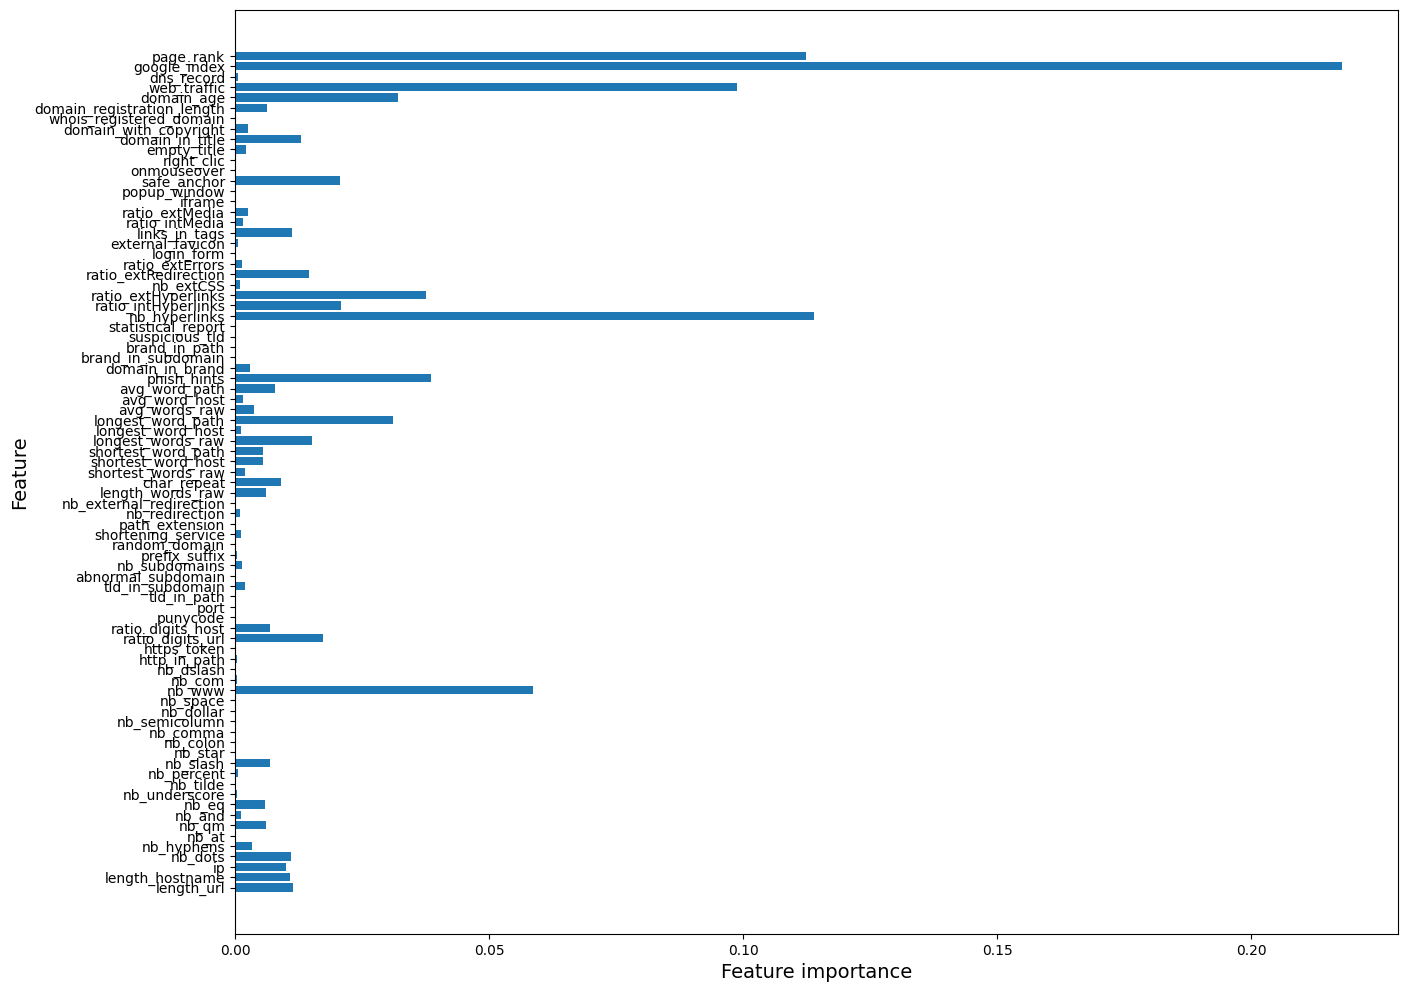

In [30]:
#checking the feature importance in the model
plt.figure(figsize=(15, 12)) 
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns, fontsize=10)  # Mengatur ukuran font agar lebih jelas
plt.xlabel("Feature importance", fontsize=14)  # Ukuran font label sumbu X
plt.ylabel("Feature", fontsize=14)  # Ukuran font label sumbu Y
plt.show()

**Storing the results:**

### **7.3. XGBoost Classifier**
XGBoost (eXtreme Gradient Boosting) adalah algoritma machine learning yang sangat populer dan banyak digunakan untuk tugas klasifikasi dan regresi. XGBoost merupakan implementasi dari teknik gradient boosting yang menggabungkan beberapa pohon keputusan untuk membuat prediksi yang lebih akurat. Teknik ini membangun model secara bertahap, di mana setiap pohon keputusan yang baru dirancang untuk mengoreksi kesalahan yang dilakukan oleh pohon keputusan sebelumnya.

Keunggulan utama XGBoost terletak pada kecepatan dan performa yang sangat tinggi, yang menjadikannya sangat efisien dalam menangani dataset besar dan kompleks. Salah satu fitur unggulan XGBoost adalah regularisasi, yang berfungsi untuk mengurangi risiko overfitting—suatu kondisi di mana model terlalu menyesuaikan diri dengan data pelatihan sehingga tidak dapat beradaptasi dengan baik pada data baru. Dengan regularisasi ini, XGBoost dapat menghasilkan model yang lebih stabil dan generalis.

XGBoost juga mendukung paralelisasi proses pembelajaran, yang berarti dapat menjalankan proses pelatihan dengan lebih cepat, terutama pada data yang sangat besar. Selain itu, XGBoost mampu mengelola atribut yang tidak relevan atau berisik (noise) dalam dataset dengan sangat baik, yang sering kali menjadi tantangan dalam model-model lainnya

In [31]:
# XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model (lebih konservatif untuk kurangi overfitting)
xgb = XGBClassifier(
    n_estimators=200,        # nrounds
    learning_rate=0.1,       # eta
    max_depth=4,             # maxdepth
    reg_lambda=1.0,          # lambda
    reg_alpha=0.1,           # alpha
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=2,
    random_state=12,
    n_jobs=-1,
    eval_metric="logloss"
)

# fit the model
xgb.fit(X_train, y_train)

# predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Performance Evaluation:**

In [32]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.986
XGBoost : Accuracy on test Data: 0.972


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_test_xgb, digits=3))
print(confusion_matrix(y_test, y_test_xgb))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))


              precision    recall  f1-score   support

           0      0.970     0.974     0.972      1143
           1      0.974     0.970     0.972      1143

    accuracy                          0.972      2286
   macro avg      0.972     0.972     0.972      2286
weighted avg      0.972     0.972     0.972      2286

[[1113   30]
 [  34 1109]]
AUC: 0.9959156461522799


### **7.4 Stacking Ensemble**

**Storing the results:**

In [34]:
# Stacking Ensemble (RF + XGB -> Logistic Regression)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_learners = [
    ("rf", forest),
    ("xgb", xgb),
]

meta_learner = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=12)

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

y_test_stack = stack_model.predict(X_test)
y_train_stack = stack_model.predict(X_train)

acc_train_stack = accuracy_score(y_train, y_train_stack)
acc_test_stack = accuracy_score(y_test, y_test_stack)

print("Stacking: Accuracy on training Data: {:.3f}".format(acc_train_stack))
print("Stacking: Accuracy on test Data: {:.3f}".format(acc_test_stack))


Stacking: Accuracy on training Data: 0.983
Stacking: Accuracy on test Data: 0.973


## **8. Perbandingan Model**
Tahap ini menampilkan tabel perbandingan performa model yang sudah disimpan dengan `storeResults`, lalu mengurutkannya berdasarkan performa test.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else y_pred

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_eval, y_prob)
    except Exception:
        auc = np.nan

    return {
        "ML Model": name,
        "Accuracy": round(accuracy_score(y_eval, y_pred), 3),
        "Precision": round(precision_score(y_eval, y_pred, zero_division=0), 3),
        "Recall": round(recall_score(y_eval, y_pred, zero_division=0), 3),
        "F1 Score": round(f1_score(y_eval, y_pred, zero_division=0), 3),
        "AUC": round(auc, 3) if not np.isnan(auc) else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

detail_rows = []
if "forest" in globals():
    detail_rows.append(evaluate_model("Random Forest", forest, X_test, y_test))
if "xgb" in globals():
    detail_rows.append(evaluate_model("XGBoost", xgb, X_test, y_test))
if "stack_model" in globals():
    detail_rows.append(evaluate_model("Stacking (RF+XGB+LR)", stack_model, X_test, y_test))

detail_df = pd.DataFrame(detail_rows).sort_values(
    by=["Accuracy", "F1 Score"], ascending=False
).reset_index(drop=True)

detail_df

,ML Model,Accuracy,Precision,Recall,F1 Score,AUC,TN,FP,FN,TP
0,Stacking (RF+XGB+LR),0.973,0.975,0.971,0.973,0.995,1115,28,33,1110
1,XGBoost,0.972,0.974,0.970,0.972,0.996,1113,30,34,1109
2,Random Forest,0.947,0.951,0.941,0.946,0.989,1088,55,67,1076
